# Testing additive hypothesis

For neurons that are stim-tuned during the maintenance period, are they additively recruited in load-3 trials to maintain memory of stimulus information?

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-06-05 16:14:42.679668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 16:14:42.688115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-05 16:14:42.697065: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-05 16:14:42.699736: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 16:14:42.706962: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

## load data

In [3]:
# the two models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [4]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
load_tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)


(536, 1000, 450)


## plot example trial activity

In [6]:
trial_stim_pattern = [1, 2, 3] # example

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]
print(trial_idxs)
print(trial_labels[trial_idxs])

[112 161 166 183 185 308 309 310 311 312 313 314 315 316 317 318 319]
[[ 3. -1.  1.  2.  3.  0.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  2.]
 [ 3. -1.  1.  2.  3.  0.]
 [ 3. -1.  1.  2.  3.  0.]
 [ 3. -1.  1.  2.  3.  0.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  1.]
 [ 3.  1.  1.  2.  3.  2.]
 [ 3.  1.  1.  2.  3.  2.]
 [ 3.  1.  1.  2.  3.  2.]
 [ 3.  1.  1.  2.  3.  3.]
 [ 3.  1.  1.  2.  3.  3.]
 [ 3.  1.  1.  2.  3.  3.]]


In [13]:
neuron_idxs_tuning[neuron_idxs_sort]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3.])

### plotting trials separately

/tmp/ipykernel_39390/2415961480.py:22: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/2415961480.py:23: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


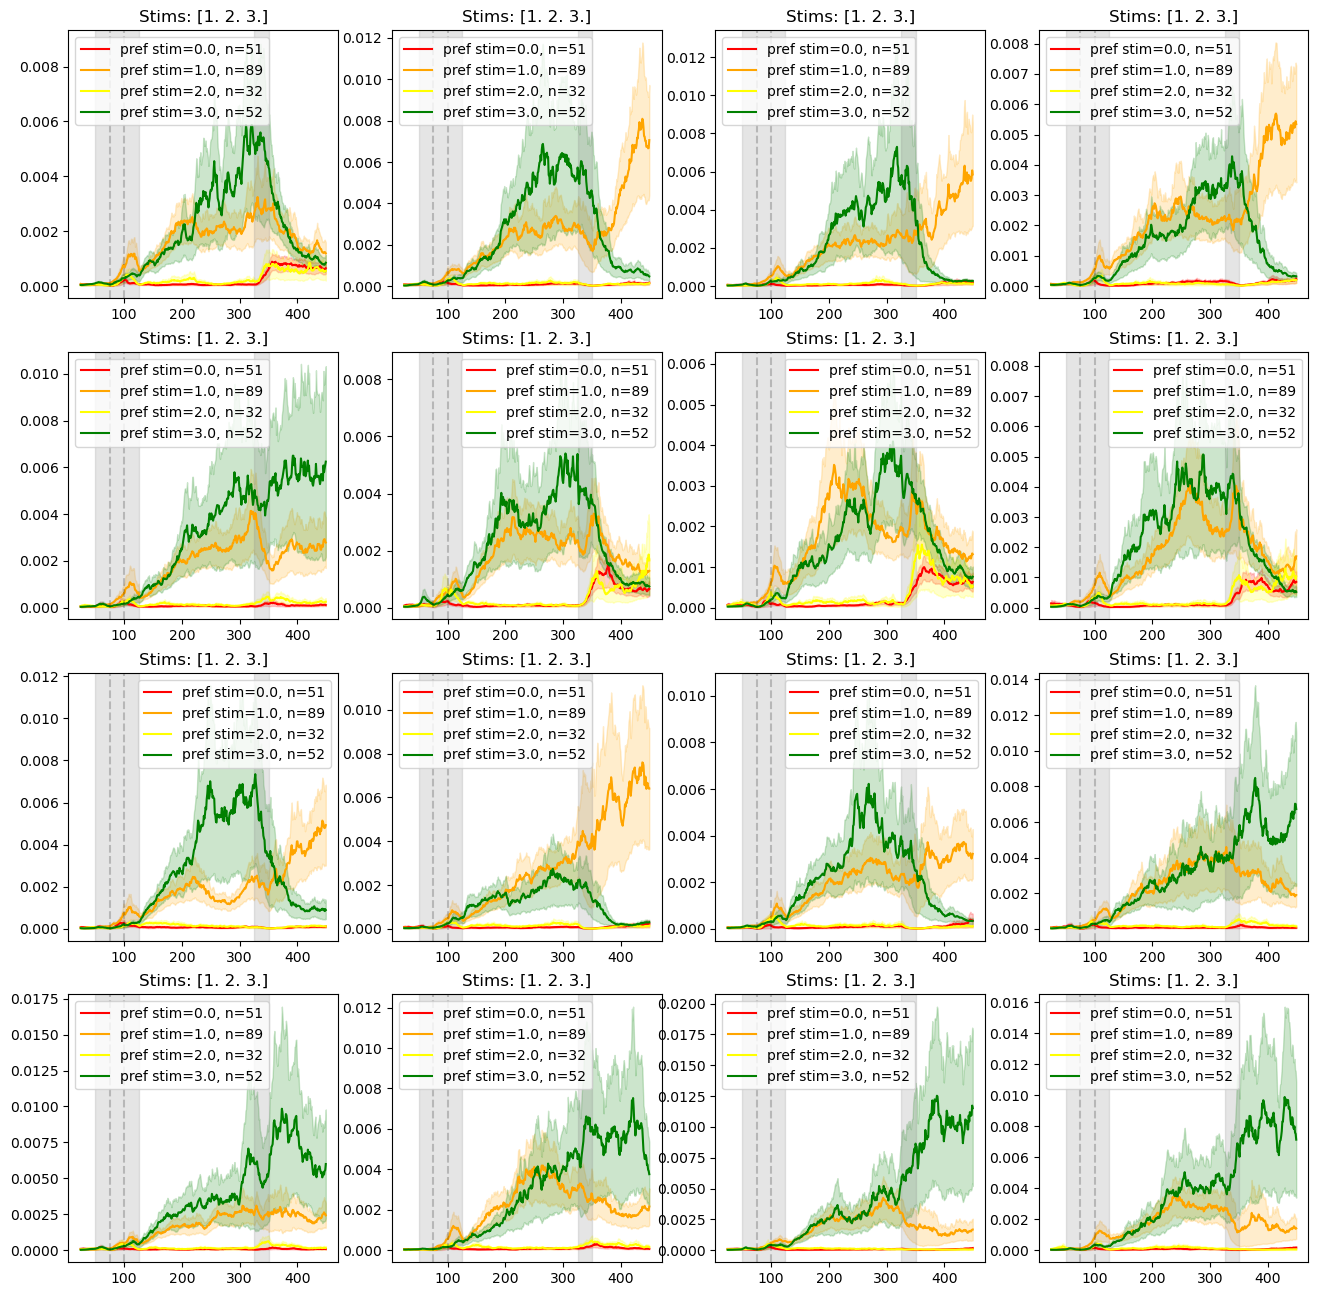

In [24]:
trial_stim_pattern = [1, 2, 3] # example 
load=3

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

trial_frs = rates_data[trial_idxs, :, :]
trial_frs[:,:,:25] = np.nan
fig, axs = plt.subplots(4,4, figsize=(16,16))
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, trial_fr in enumerate(trial_frs[:16]):
    ax = axs[i]
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_labels[trial_idxs[i], 2:5]}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/2016361559.py:22: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/2016361559.py:23: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


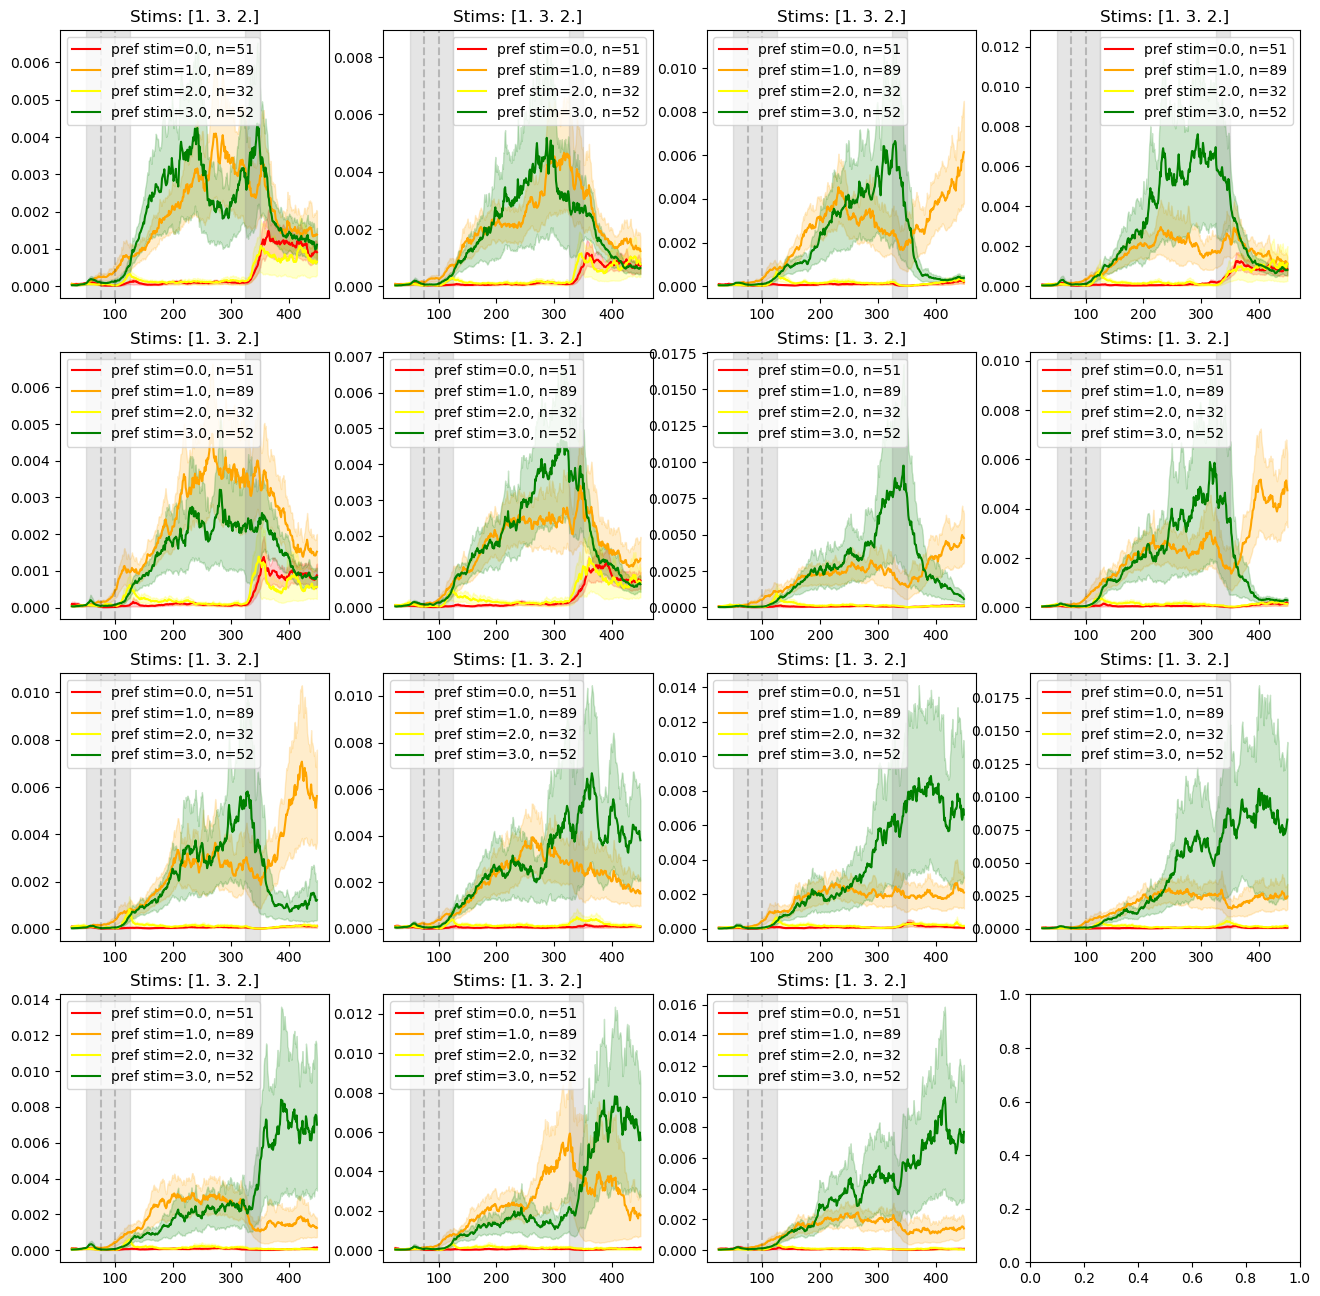

In [26]:
trial_stim_pattern = [1,3,2] # example 
load=3

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

trial_frs = rates_data[trial_idxs, :, :]
trial_frs[:,:,:25] = np.nan
fig, axs = plt.subplots(4,4, figsize=(16,16))
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, trial_fr in enumerate(trial_frs[:16]):
    ax = axs[i]
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_labels[trial_idxs[i], 2:5]}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/3216439210.py:22: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/3216439210.py:23: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


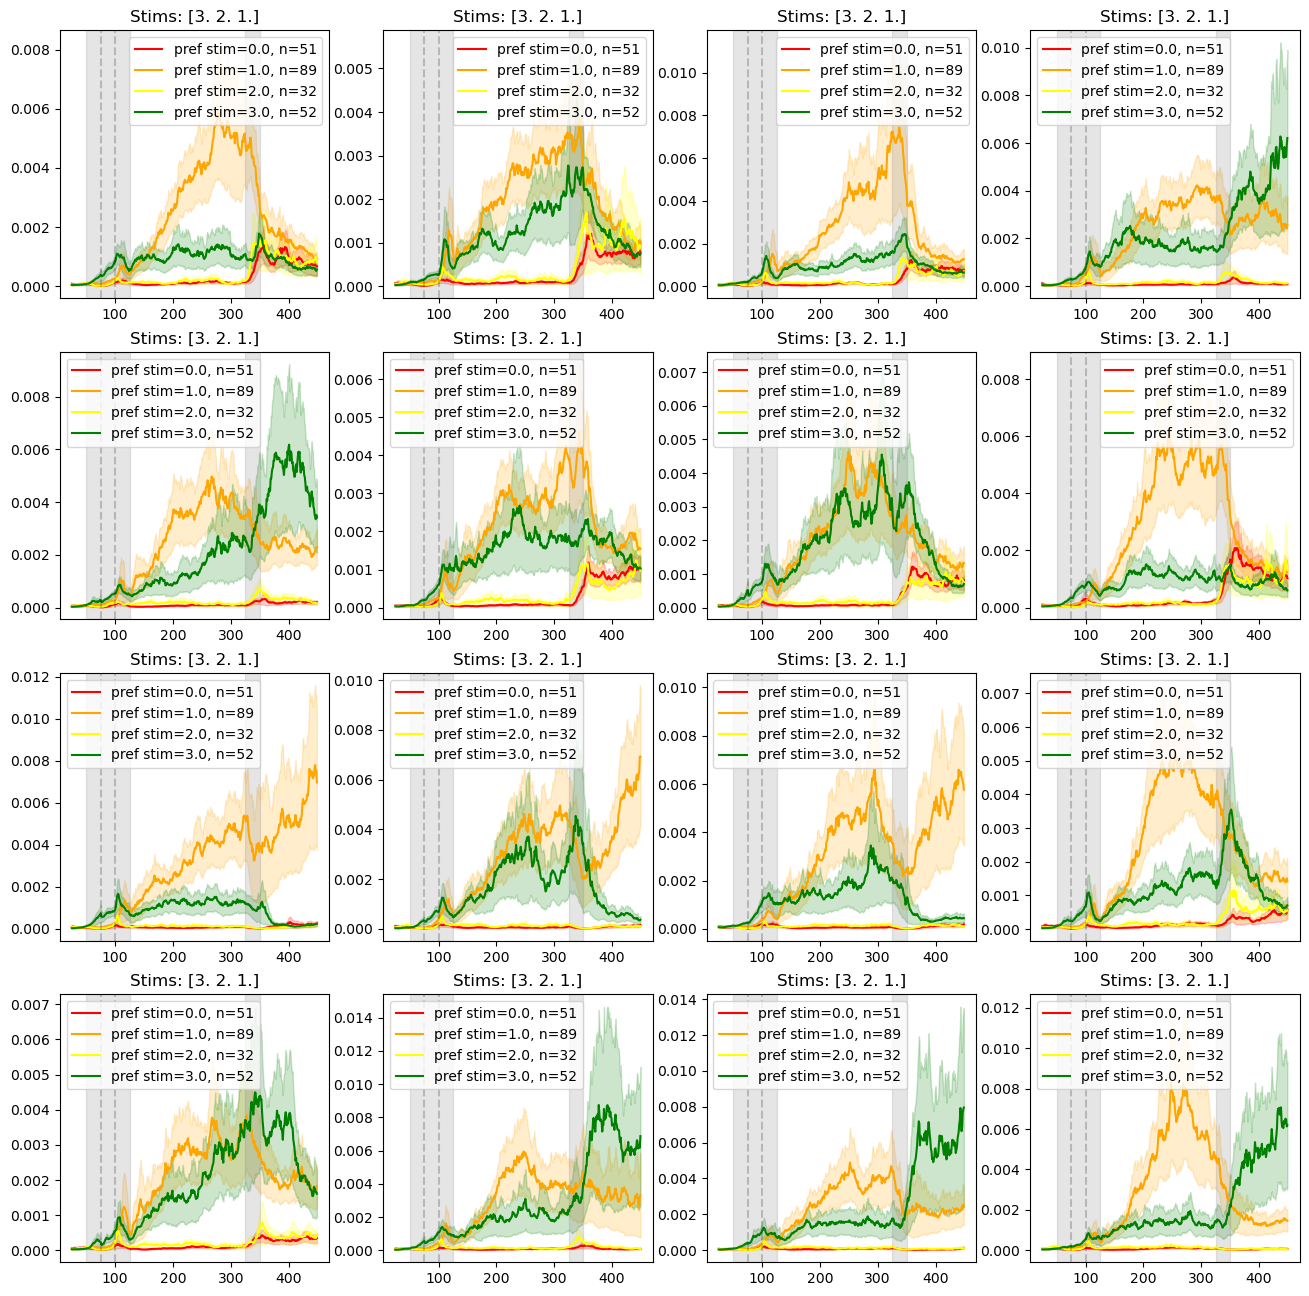

In [27]:
trial_stim_pattern = [3, 2, 1] # example 
load=3

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

trial_frs = rates_data[trial_idxs, :, :]
trial_frs[:,:,:25] = np.nan
fig, axs = plt.subplots(4,4, figsize=(16,16))
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, trial_fr in enumerate(trial_frs[:16]):
    ax = axs[i]
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_labels[trial_idxs[i], 2:5]}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/3602320574.py:22: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/3602320574.py:23: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


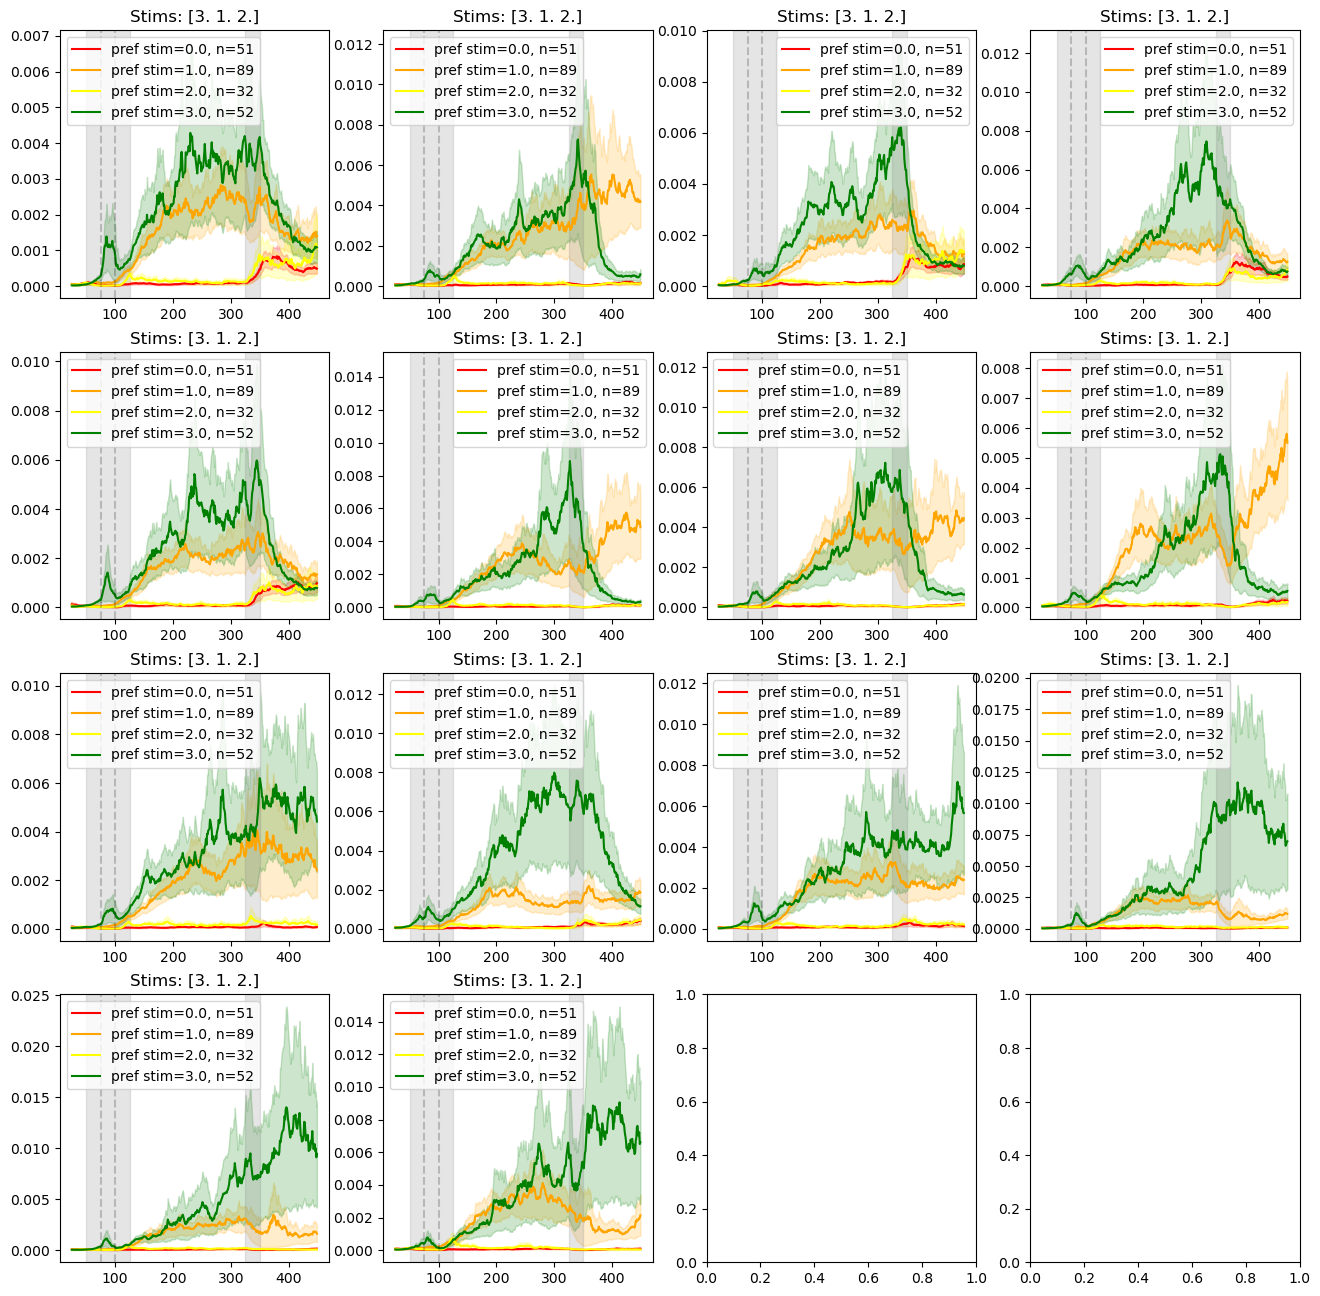

In [28]:
trial_stim_pattern = [3, 1, 2] # example 
load=3

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

trial_frs = rates_data[trial_idxs, :, :]
trial_frs[:,:,:25] = np.nan
fig, axs = plt.subplots(4,4, figsize=(16,16))
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, trial_fr in enumerate(trial_frs[:16]):
    ax = axs[i]
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_labels[trial_idxs[i], 2:5]}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/1699119083.py:22: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/1699119083.py:23: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


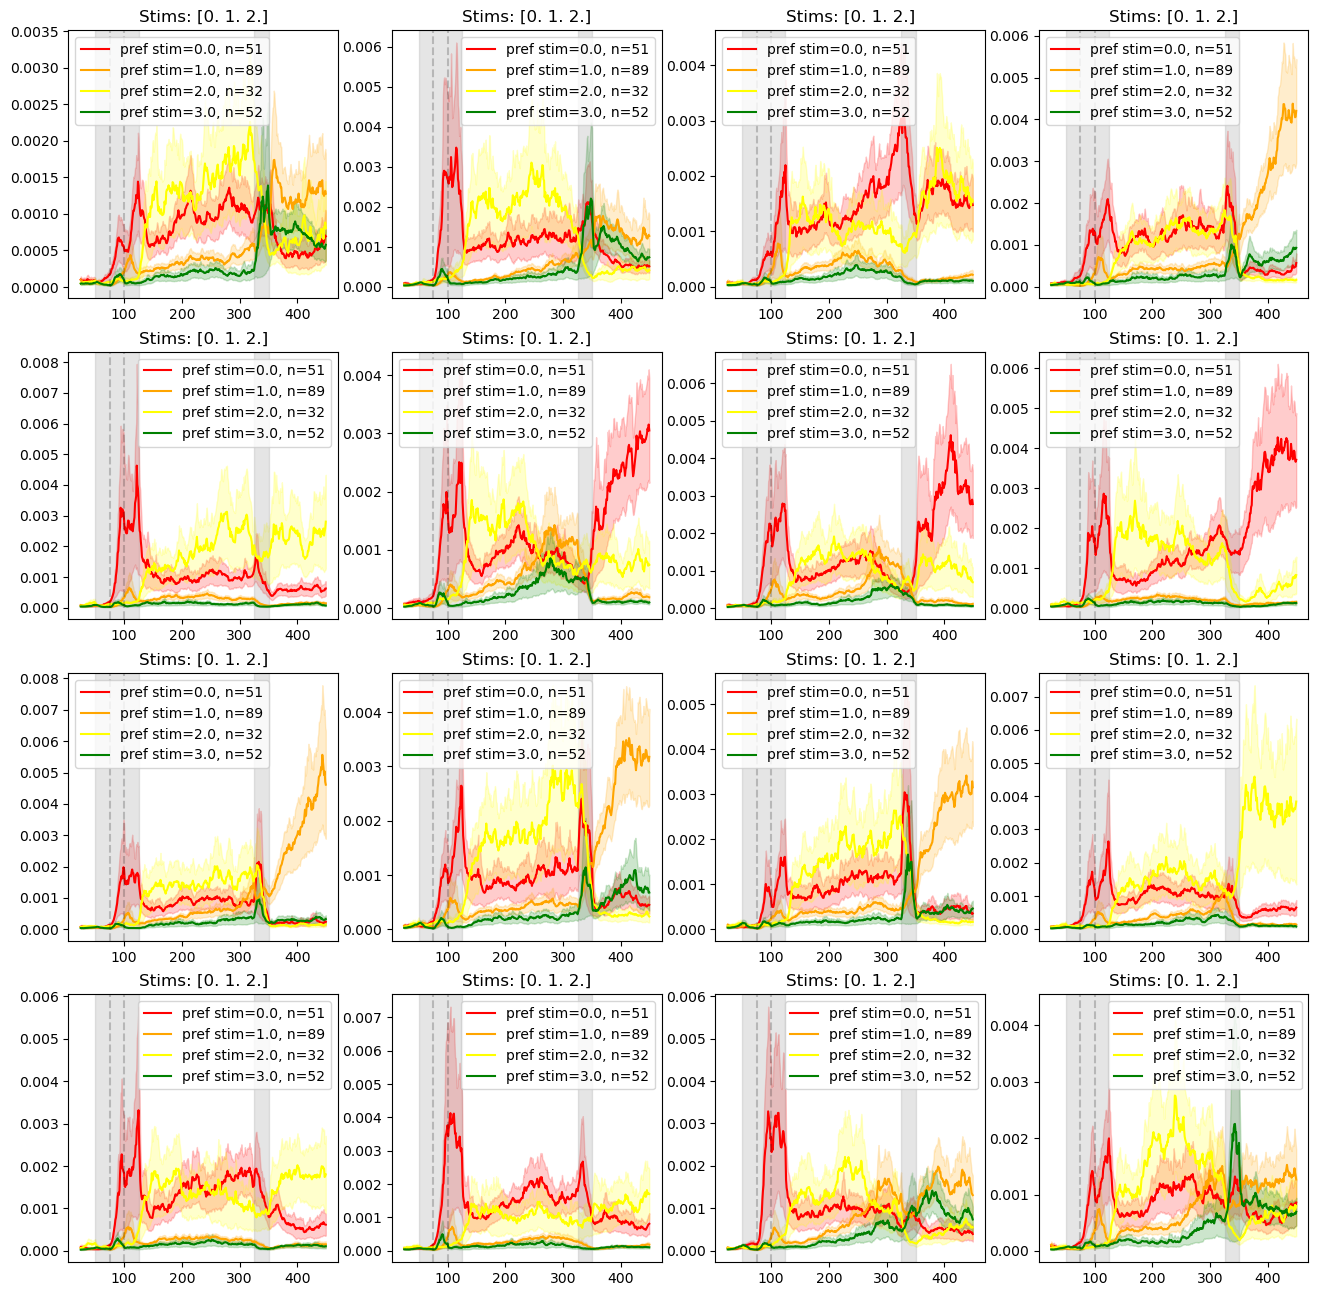

In [ ]:
trial_stim_pattern = [0, 1, 2] # example 
load=3

# find trials that match
trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

trial_frs = rates_data[trial_idxs, :, :]
trial_frs[:,:,:25] = np.nan
fig, axs = plt.subplots(4,4, figsize=(16,16))
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, trial_fr in enumerate(trial_frs[:16]):
    ax = axs[i]
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_labels[trial_idxs[i], 2:5]}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

### plotting mean of matching trials

In [29]:
from itertools import permutations

trial_stims = [1, 2, 3]
trial_stim_patterns = list(permutations(trial_stims))
trial_stim_patterns

[(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]

/tmp/ipykernel_39390/2950184054.py:22: RuntimeWarning: Mean of empty slice
  trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
/tmp/ipykernel_39390/2950184054.py:27: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/2950184054.py:28: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


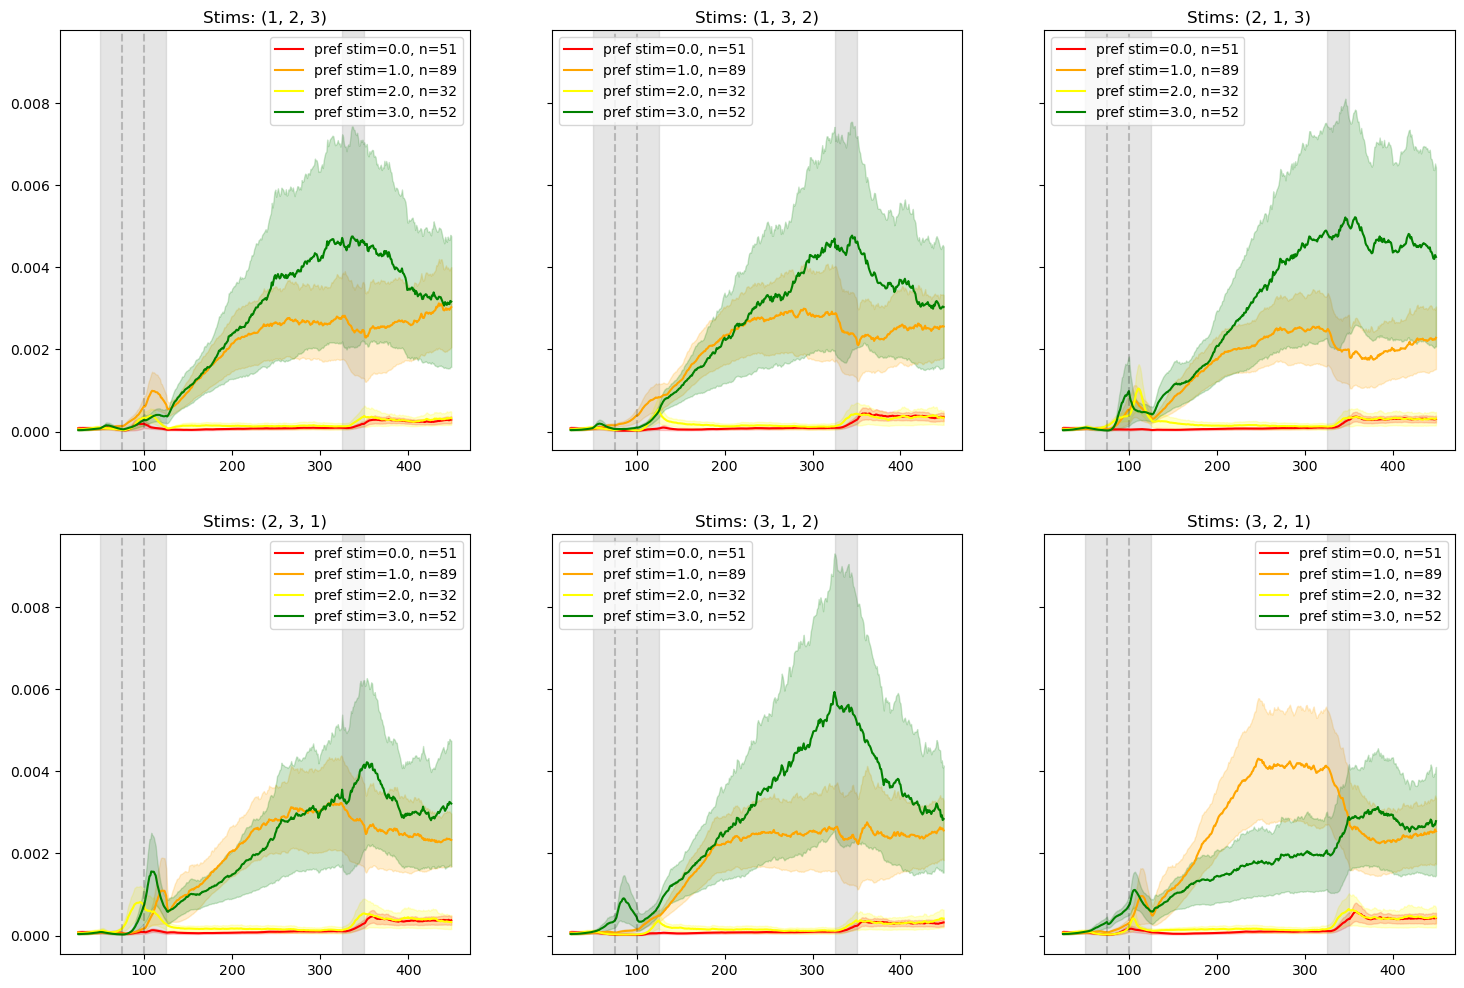

In [32]:
from itertools import permutations

trial_stims = [1, 2, 3]
trial_stim_patterns = list(permutations(trial_stims))

load=3

fig, axs = plt.subplots(2, 3, figsize=(18,12), sharey=True)
axs = axs.flatten()
for i_panel, trial_stim_pattern in enumerate(trial_stim_patterns):
    ax = axs[i_panel]
    # find trials that match
    trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

    maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
    neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
    neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
    stim1s = np.unique(neuron_idxs_tuning)

    trial_frs = rates_data[trial_idxs, :, :]
    trial_frs[:,:,:25] = np.nan
    trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
    colors = ['r','orange', 'yellow', 'g']
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_stim_pattern}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/2664344635.py:22: RuntimeWarning: Mean of empty slice
  trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
/tmp/ipykernel_39390/2664344635.py:27: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/2664344635.py:28: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


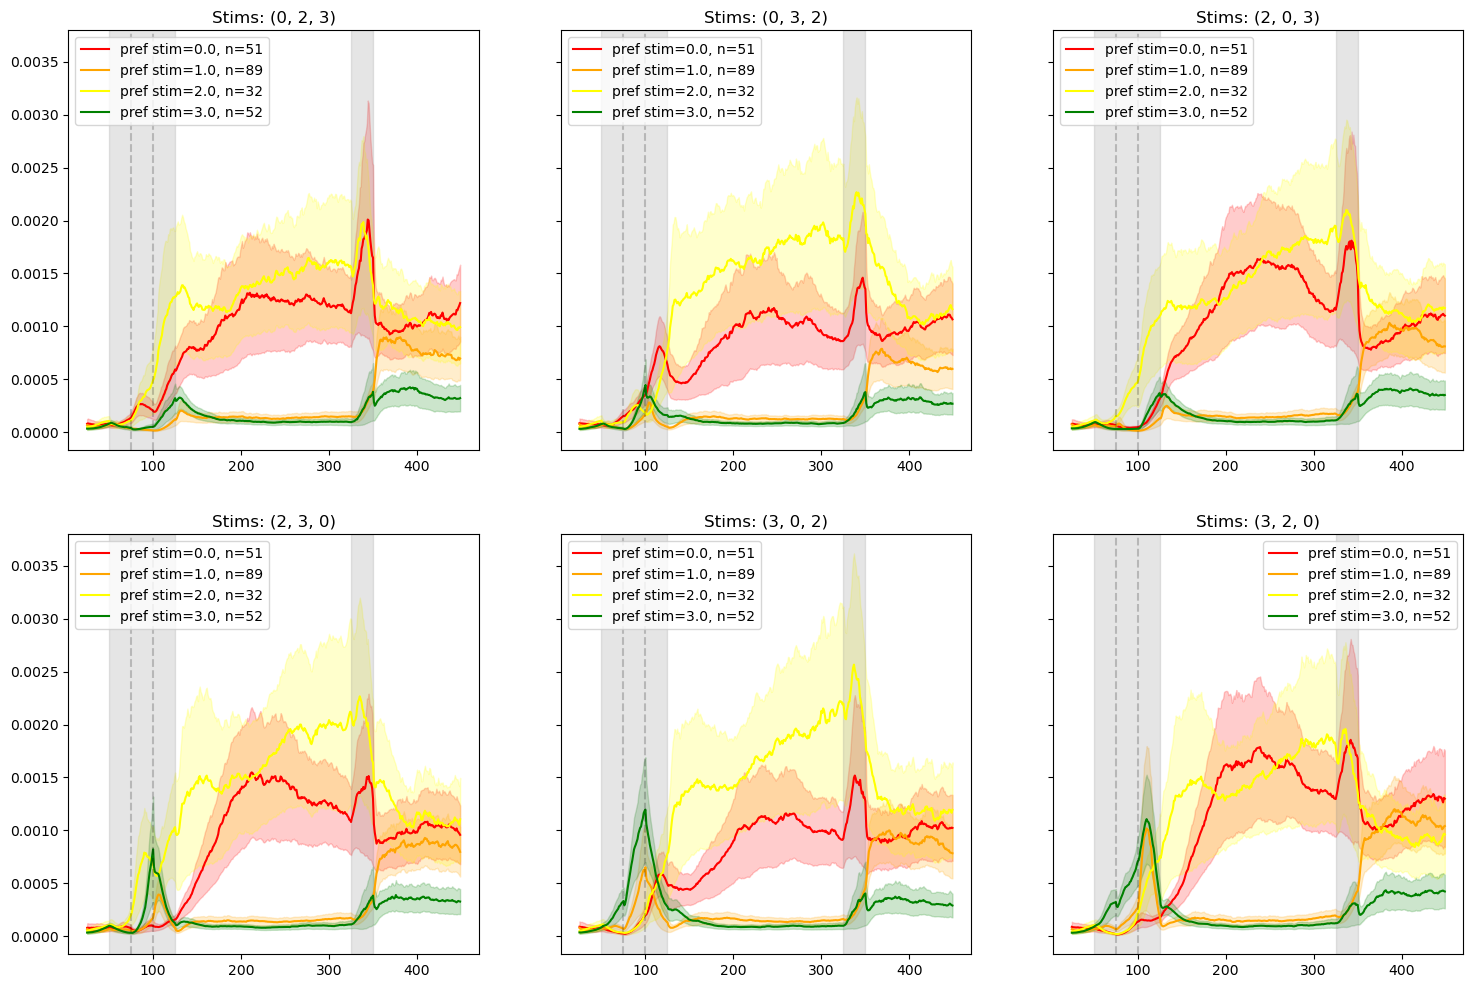

In [33]:
from itertools import permutations

trial_stims = [0, 2, 3]
trial_stim_patterns = list(permutations(trial_stims))

load=3

fig, axs = plt.subplots(2, 3, figsize=(18,12), sharey=True)
axs = axs.flatten()
for i_panel, trial_stim_pattern in enumerate(trial_stim_patterns):
    ax = axs[i_panel]
    # find trials that match
    trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

    maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
    neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
    neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
    stim1s = np.unique(neuron_idxs_tuning)

    trial_frs = rates_data[trial_idxs, :, :]
    trial_frs[:,:,:25] = np.nan
    trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
    colors = ['r','orange', 'yellow', 'g']
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_stim_pattern}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/3179436959.py:22: RuntimeWarning: Mean of empty slice
  trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
/tmp/ipykernel_39390/3179436959.py:27: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/3179436959.py:28: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


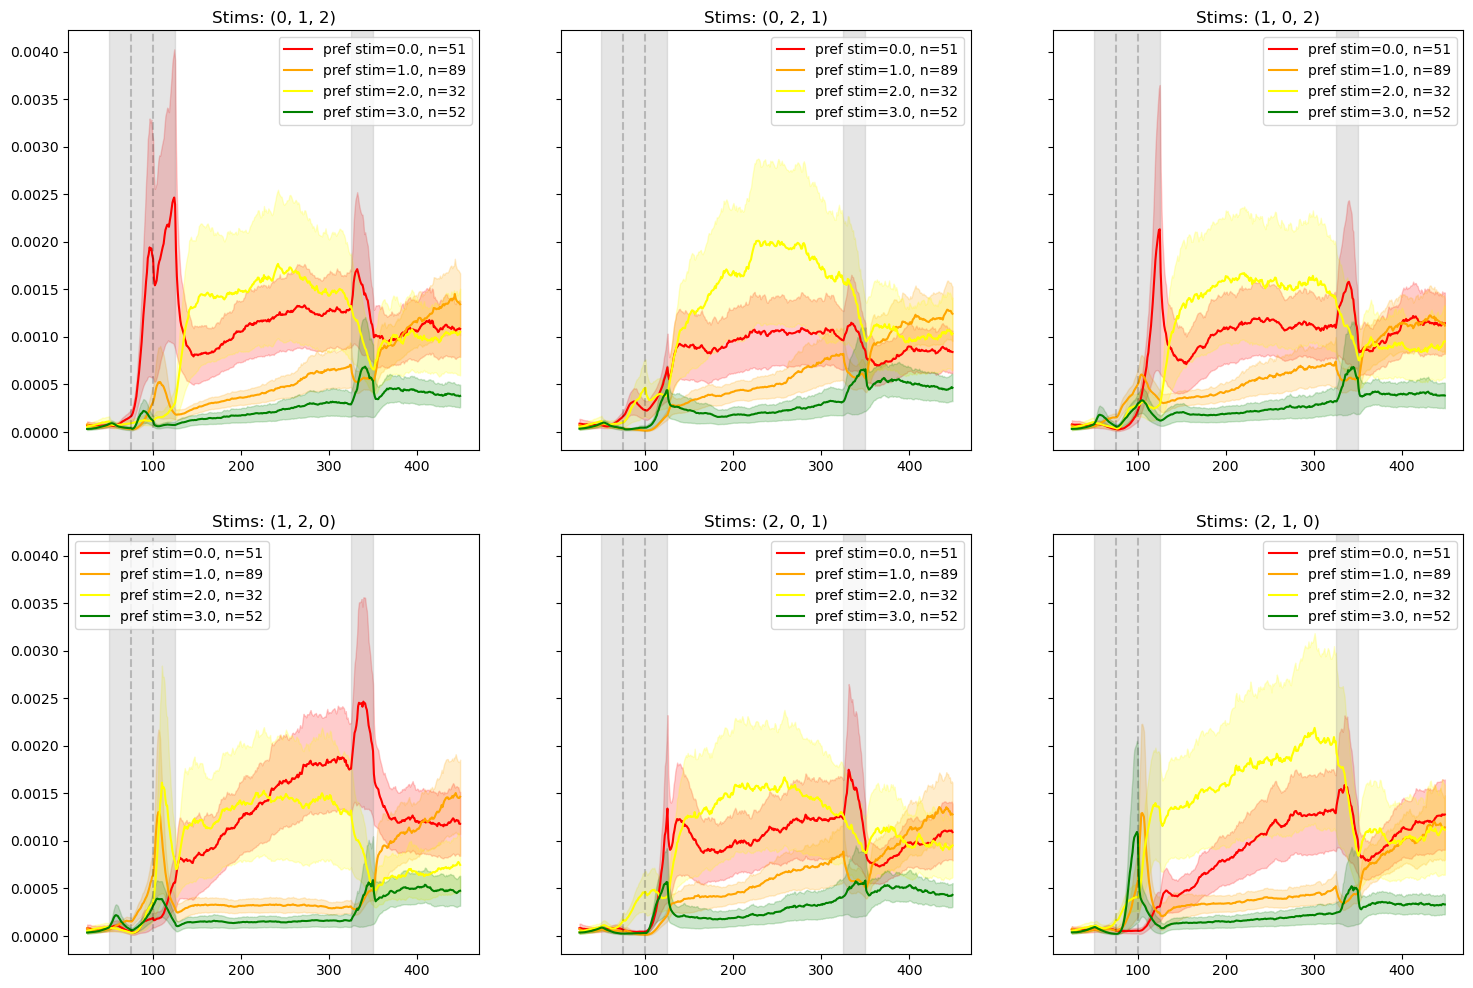

In [35]:
from itertools import permutations

trial_stims = [0, 1, 2]
trial_stim_patterns = list(permutations(trial_stims))

load=3

fig, axs = plt.subplots(2, 3, figsize=(18,12), sharey=True)
axs = axs.flatten()
for i_panel, trial_stim_pattern in enumerate(trial_stim_patterns):
    ax = axs[i_panel]
    # find trials that match
    trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

    maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
    neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
    neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
    stim1s = np.unique(neuron_idxs_tuning)

    trial_frs = rates_data[trial_idxs, :, :]
    trial_frs[:,:,:25] = np.nan
    trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
    colors = ['r','orange', 'yellow', 'g']
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_stim_pattern}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

/tmp/ipykernel_39390/1199469771.py:22: RuntimeWarning: Mean of empty slice
  trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
/tmp/ipykernel_39390/1199469771.py:27: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_39390/1199469771.py:28: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


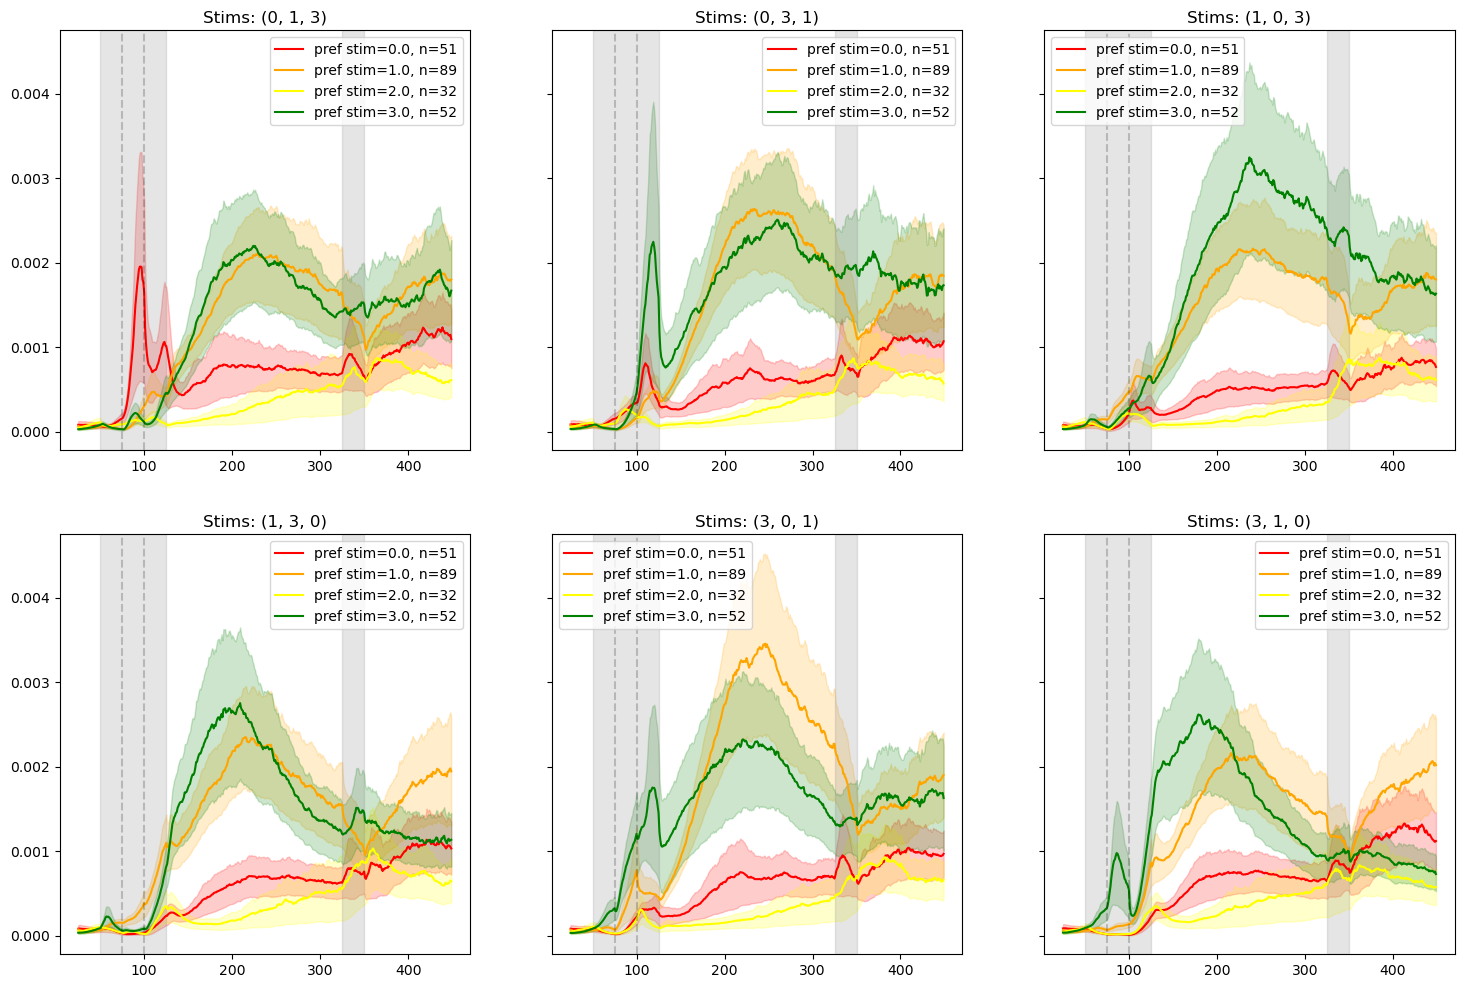

In [36]:
from itertools import permutations

trial_stims = [0, 1, 3]
trial_stim_patterns = list(permutations(trial_stims))

load=3

fig, axs = plt.subplots(2, 3, figsize=(18,12), sharey=True)
axs = axs.flatten()
for i_panel, trial_stim_pattern in enumerate(trial_stim_patterns):
    ax = axs[i_panel]
    # find trials that match
    trial_idxs = np.where(np.all(trial_labels[:,[2,3,4]] == [trial_stim_pattern], axis=1))[0]

    maint_tuned_only = np.where((np.isnan(stim1_stimtuning)) & ~np.isnan(maint_stimtuning))[0] # maint-tuned, not stim-tuned
    neuron_idxs = np.intersect1d(maint_tuned_only, exc_ind) # example: only look at excitatory neurons
    neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
    stim1s = np.unique(neuron_idxs_tuning)

    trial_frs = rates_data[trial_idxs, :, :]
    trial_frs[:,:,:25] = np.nan
    trial_fr = np.nanmean(trial_frs, axis=0) # neurons x time
    colors = ['r','orange', 'yellow', 'g']
    for j, stim1 in enumerate(stim1s):
        these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim1]
        trial_rate = trial_fr[these_neuron_idxs, :]
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'pref stim={stim1}, n={len(these_neuron_idxs)}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate-sem_rate, mean_rate+sem_rate, color=colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    
    ax.set_title(f'Stims: {trial_stim_pattern}')
    ax.legend()
# fig.suptitle(f'Maint stim-tuned but not stim1-tuned, load {load}')

## lesion groups